# Heatmap temporelle

Ce notebook construit une heatmap simple à partir de `triptyques_temps_lieux.csv`.

- les lignes représentent les repères temporels
- les colonnes représentent les heures
- les valeurs représentent le nombre de triptyques

Le filtre sur les déplacements est optionnel.

In [12]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [13]:
CSV_PATH = '../results/csv_triptyques/triptyques_temps_lieux.csv'
ONLY_DEPLACEMENTS = False

In [14]:
df = pd.read_csv(CSV_PATH)

if ONLY_DEPLACEMENTS:
    if df['deplacement'].dtype == object:
        df = df[df['deplacement'].astype(str).str.lower().isin(['true', '1'])].copy()
    else:
        df = df[df['deplacement'] == True].copy()

df.head()

,triplet_id,chapter,Num_paragr,Num_phrase,Sentence_index,Phrase,Sujet,Verbe,Objet,Lemme_verbe,...,jour_romanesque_precedent,time_texte_auto,time_code_auto,date_jour_auto,jour_romanesque_auto,source_temps_auto,lieux_labels,a_personnage,a_lieu,deplacement
0,0,1,0,0,1,"En l' année 1872, la maison portant le numéro ...",NaN,portant,le numéro 7 de Saville-row Burlington Gardens-...,porter,...,NaN,l' année 1872,1872-00-00-00,NaN,NaN,phrase,"['maison_fogg', 'rue_fogg']",False,True,False
1,1,1,0,0,1,"En l' année 1872, la maison portant le numéro ...",Sheridan,mourut,en 1814,mourir,...,NaN,en 1814,1814-00-00-00,NaN,NaN,phrase,[],False,False,False
2,2,1,0,0,1,"En l' année 1872, la maison portant le numéro ...",la maison,habitée,En l'année 1872,habiter,...,NaN,l' année 1872,1872-00-00-00,NaN,NaN,phrase,['maison_fogg'],False,True,False
3,3,1,0,0,1,"En l' année 1872, la maison portant le numéro ...",la maison,habitée,par Phileas Fogg esq.,habiter,...,NaN,l' année 1872,1872-00-00-00,NaN,NaN,phrase,['maison_fogg'],True,True,True
4,4,1,0,0,1,"En l' année 1872, la maison portant le numéro ...",la maison,habitée,l'un des membres les plus singuliers et les pl...,habiter,...,NaN,l' année 1872,1872-00-00-00,NaN,NaN,phrase,"['maison_fogg', 'reform_club']",True,True,True


In [15]:
pat = re.compile(r'^(\d{4})[-_](\d{2})[-_](\d{2})(?:[-_](\d{2}))?(?:[-_](\d{2}))?$')

def parse_time_code(code):
    if pd.isna(code):
        return pd.Series({'annee': np.nan, 'mois': np.nan, 'jour': np.nan, 'heure': np.nan,
                          'precision': np.nan, 'time_label': np.nan, 'hour_label': np.nan,
                          'sort_key': np.nan})

    code = str(code).strip()
    m = pat.match(code)
    if not m:
        return pd.Series({'annee': np.nan, 'mois': np.nan, 'jour': np.nan, 'heure': np.nan,
                          'precision': np.nan, 'time_label': np.nan, 'hour_label': np.nan,
                          'sort_key': np.nan})

    annee, mois, jour, heure, minute = m.groups()
    annee_i = int(annee)
    mois_i = int(mois)
    jour_i = int(jour)
    heure_i = int(heure) if heure is not None and heure.isdigit() else np.nan

    if mois_i == 0 and jour_i == 0:
        precision = 'annee'
        time_label = f'{annee_i}'
        sort_key = annee_i * 10000
    elif mois_i > 0 and jour_i == 0:
        precision = 'mois'
        time_label = f'{annee_i:04d}-{mois_i:02d}'
        sort_key = annee_i * 10000 + mois_i * 100
    else:
        precision = 'jour'
        time_label = f'{annee_i:04d}-{mois_i:02d}-{jour_i:02d}'
        sort_key = annee_i * 10000 + mois_i * 100 + jour_i

    if pd.isna(heure_i):
        hour_label = 'sans heure'
    elif (mois_i == 0 or jour_i == 0) and heure_i == 0:
        hour_label = 'sans heure'
    else:
        hour_label = f'{int(heure_i):02d}h'

    return pd.Series({'annee': annee_i, 'mois': mois_i, 'jour': jour_i, 'heure': heure_i,
                      'precision': precision, 'time_label': time_label, 'hour_label': hour_label,
                      'sort_key': sort_key})

parsed = df['time_code_auto'].apply(parse_time_code)
df = pd.concat([df, parsed], axis=1)
df = df[df['time_label'].notna()].copy()

df[['time_code_auto', 'time_label', 'hour_label']].head(10)

,time_code_auto,time_label,hour_label
0,1872-00-00-00,1872,sans heure
1,1814-00-00-00,1814,sans heure
2,1872-00-00-00,1872,sans heure
3,1872-00-00-00,1872,sans heure
4,1872-00-00-00,1872,sans heure
5,1872-00-00-00,1872,sans heure
6,1872-00-00-00,1872,sans heure
7,1872-00-00-00,1872,sans heure
8,1872-00-00-00,1872,sans heure
9,1872-00-00-00,1872,sans heure


In [16]:
row_order = (
    df[['time_label', 'sort_key']]
    .drop_duplicates()
    .sort_values(['sort_key', 'time_label'])['time_label']
    .tolist()
)

col_order = [f'{h:02d}h' for h in range(24)] + ['sans heure']

pivot = pd.pivot_table(
    df,
    index='time_label',
    columns='hour_label',
    values='triplet_id',
    aggfunc='count',
    fill_value=0
)

pivot = pivot.reindex(index=row_order)
for c in col_order:
    if c not in pivot.columns:
        pivot[c] = 0
pivot = pivot[col_order]

pivot

hour_label,00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,...,15h,16h,17h,18h,19h,20h,21h,22h,23h,sans heure
time_label,,,,,,,,,,,,,,,,,,,,,
1772,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,63
1814,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1862,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
1867,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,107
1872,0,0,0,0,0,0,0,0,48,0,...,0,0,0,0,0,0,0,0,0,80
1872-09-29,135,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1872-10-02,22,0,0,0,0,0,0,0,0,0,...,3,0,8,94,25,205,0,0,0,0
1872-10-03,19,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1872-10-05,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


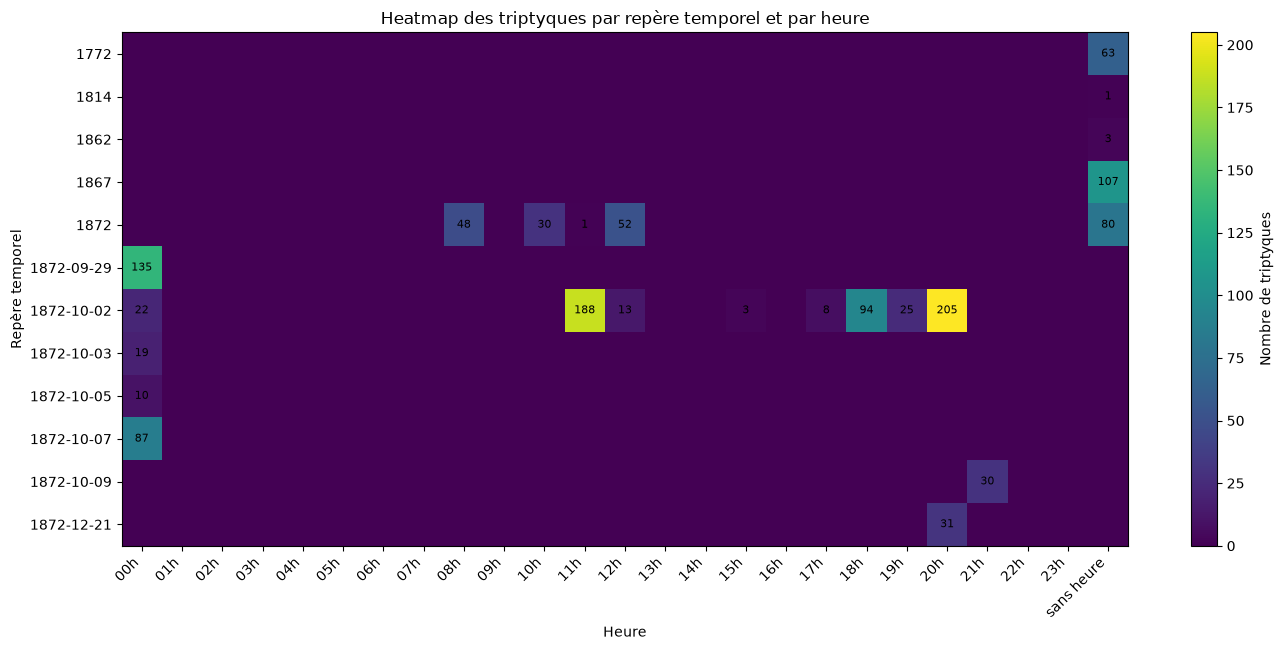

In [17]:
fig, ax = plt.subplots(figsize=(14, max(5, 0.55 * len(pivot.index))))
im = ax.imshow(pivot.to_numpy(), aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Heure')
ax.set_ylabel('Repère temporel')
ax.set_title('Heatmap des triptyques par repère temporel et par heure')

arr = pivot.to_numpy()
for i in range(arr.shape[0]):
    for j in range(arr.shape[1]):
        v = int(arr[i, j])
        if v != 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Nombre de triptyques')
plt.tight_layout()
plt.show()

rajouter un temps pour chaque triptyques => si jamais changement => alors triptyque clé

Regarder les marqueurs de temps qui ne sont pas annoté comme "TIME" => du genre 'depuis' 'apres' => peut atre avec une liste de mots plus des listes UD qui lient ca à l'événement => génération automatique 

pour ceux qui sont annotés en TIME (on fait un programme qui retourne le temps si jamais on a bien un temps absolu) on regarde le temps du verbe aussi pour voir si jamais on lie ce temps => il y a des temps qui sont cadres d'autres qui sont bon pour qu'un seul triptyques ("Sheridan mourut en 1814") 

Sinon apres comme le temps on ajoute

vehicule

prends les diptyques => c'est a dire pas seulement lorqu'il y a un lieu => personnage verbe => on rajouterait automatiquement un lieu, mais en soit c'est une action du personnage

ajouter dynamouv

PRESENTATION : 

reprise de ce qu'a fait elijah

trucs sur les formats .conllu

illustrer avec exemples